In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")


In [2]:
import pandas as pd  # Import pandas library and assign it the alias 'pd'

df = pd.read_csv("cardekho.csv")

print("="*70)
print("FIRST FIVE ROWS")
print("="*70)
print(df.head())

print("\nDataset Shape :", df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows :", df.duplicated().sum())

FIRST FIVE ROWS
                           name  year  selling_price  km_driven    fuel  \
0        Maruti Swift Dzire VDI  2014         450000     145500  Diesel   
1  Skoda Rapid 1.5 TDI Ambition  2014         370000     120000  Diesel   
2      Honda City 2017-2020 EXi  2006         158000     140000  Petrol   
3     Hyundai i20 Sportz Diesel  2010         225000     127000  Diesel   
4        Maruti Swift VXI BSIII  2007         130000     120000  Petrol   

  seller_type transmission         owner  mileage(km/ltr/kg)  engine  \
0  Individual       Manual   First Owner               23.40  1248.0   
1  Individual       Manual  Second Owner               21.14  1498.0   
2  Individual       Manual   Third Owner               17.70  1497.0   
3  Individual       Manual   First Owner               23.00  1396.0   
4  Individual       Manual   First Owner               16.10  1298.0   

  max_power  seats  
0        74    5.0  
1    103.52    5.0  
2        78    5.0  
3        90    5

In [4]:
# Import required libraries
import pandas as pd
import numpy as np

df.drop_duplicates(inplace=True)

# Replace blank spaces with NaN
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

# Convert max_power into numeric
df["max_power"] = pd.to_numeric(df["max_power"], errors="coerce")

# Remove missing values
df.dropna(inplace=True)

# Standardize text columns
text_columns = ["fuel","seller_type","transmission","owner"]

for col in text_columns:
    df[col] = df[col].str.lower().str.strip()

print("\nShape After Cleaning :", df.shape)


Shape After Cleaning : (6717, 12)


In [6]:
# Import the datetime module to use datetime functions
from datetime import datetime

current_year = datetime.now().year

df["car_age"] = current_year - df["year"]

df["brand"] = df["name"].apply(lambda x: x.split()[0])

print("\nBrand Examples")
print(df["brand"].head())


Brand Examples
0     Maruti
1      Skoda
2      Honda
3    Hyundai
4     Maruti
Name: brand, dtype: object


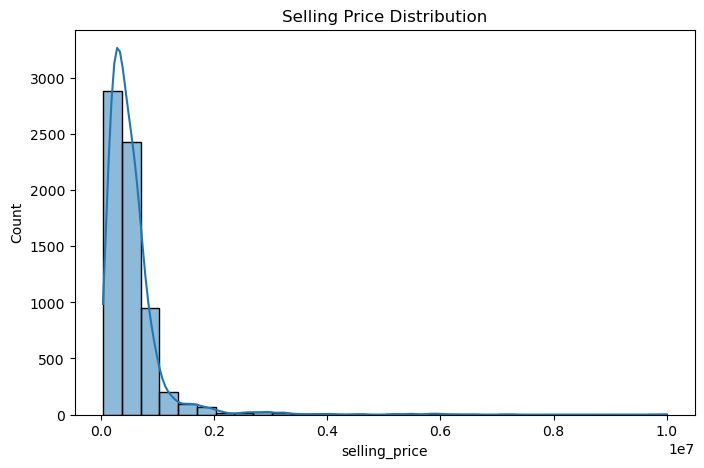

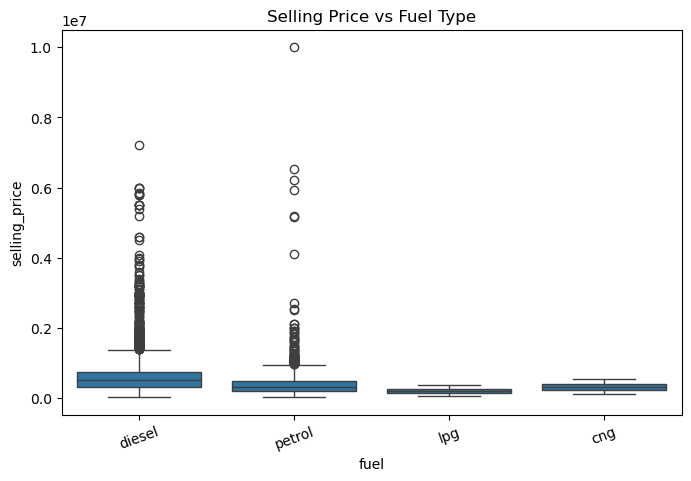

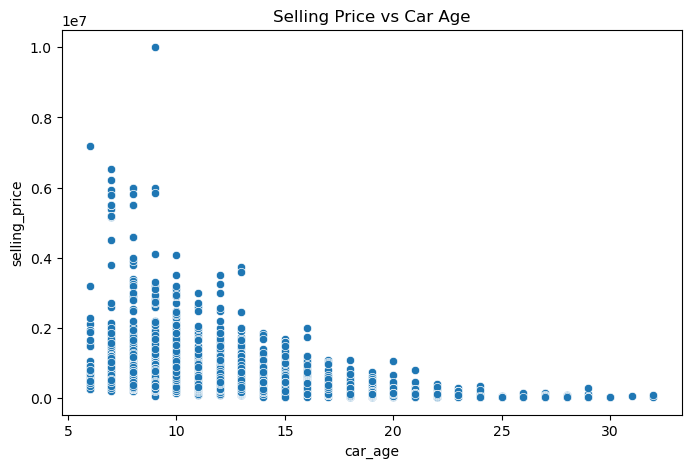

In [9]:
# Import required libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming df is your DataFrame - if not already loaded, you would need to load it
# df = pd.read_csv('your_data_file.csv')  # Example of loading data

plt.figure(figsize=(8,5))
sns.histplot(df["selling_price"], bins=30, kde=True)
plt.title("Selling Price Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x="fuel", y="selling_price", data=df)
plt.title("Selling Price vs Fuel Type")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x="car_age", y="selling_price", data=df)
plt.title("Selling Price vs Car Age")
plt.show()

In [11]:
# Import LabelEncoder from sklearn.preprocessing
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = [
    "name",
    "fuel",
    "seller_type",
    "transmission",
    "owner",
    "brand"
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

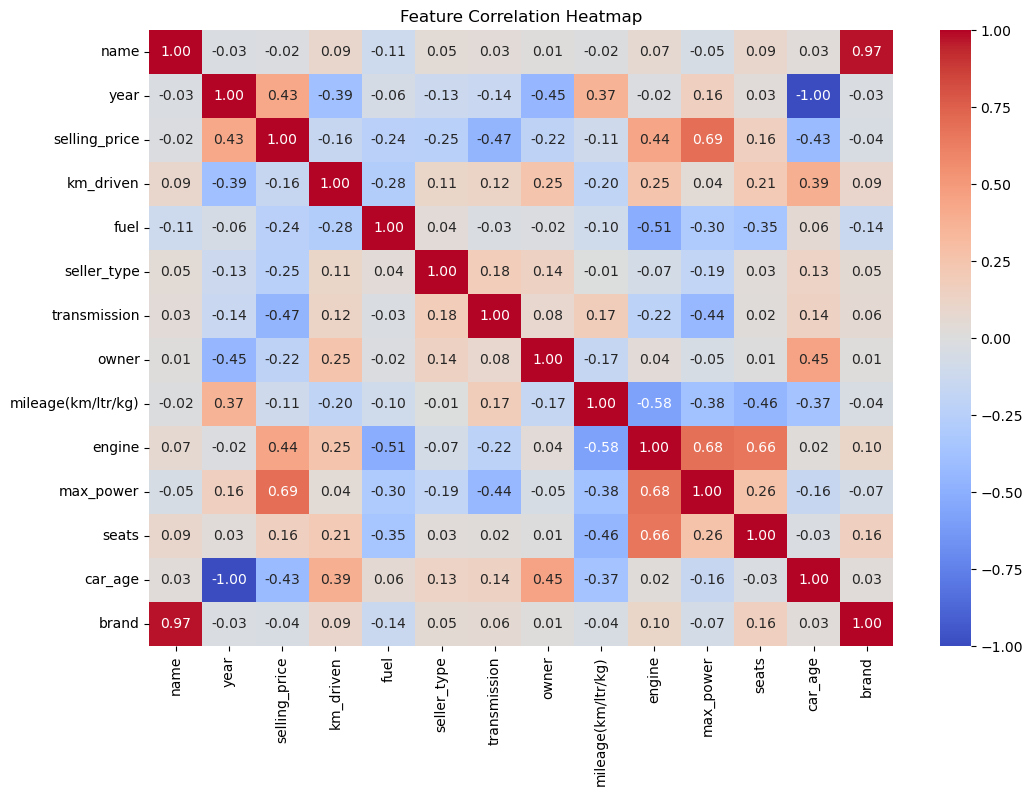

In [12]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()


In [13]:
X = df.drop("selling_price", axis=1)

y = df["selling_price"]


In [15]:
# Import the train_test_split function from sklearn
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [17]:
# Import necessary libraries
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

lr_r2 = r2_score(y_test, lr_pred)

print("\n")
print("="*70)
print("LINEAR REGRESSION")
print("="*70)

print("MAE :", lr_mae)
print("RMSE :", lr_rmse)
print("R2 Score :", lr_r2)



LINEAR REGRESSION
MAE : 168727.1376693264
RMSE : 273402.16466317326
R2 Score : 0.6593515940962026


In [21]:
# Import required libraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rf_r2 = r2_score(y_test, rf_pred)

print("\n")
print("="*70)
print("RANDOM FOREST")
print("="*70)

print("MAE :", rf_mae)
print("RMSE :", rf_rmse)
print("R2 Score :", rf_r2)



RANDOM FOREST
MAE : 72929.83558453797
RMSE : 129045.23579682651
R2 Score : 0.9241096746940306



MODEL COMPARISON
               Model            MAE           RMSE  R2 Score
0  Linear Regression  168727.137669  273402.164663  0.659352
1      Random Forest   72929.835585  129045.235797  0.924110


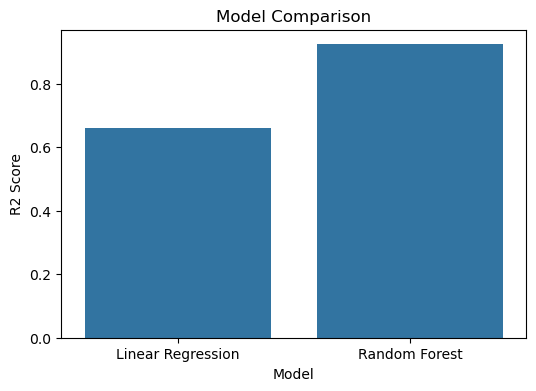

In [22]:
comparison = pd.DataFrame({
    "Model":["Linear Regression","Random Forest"],
    "MAE":[lr_mae, rf_mae],
    "RMSE":[lr_rmse, rf_rmse],
    "R2 Score":[lr_r2, rf_r2]
})

print("\nMODEL COMPARISON")
print(comparison)

plt.figure(figsize=(6,4))

sns.barplot(
    data=comparison,
    x="Model",
    y="R2 Score"
)

plt.title("Model Comparison")
plt.show()

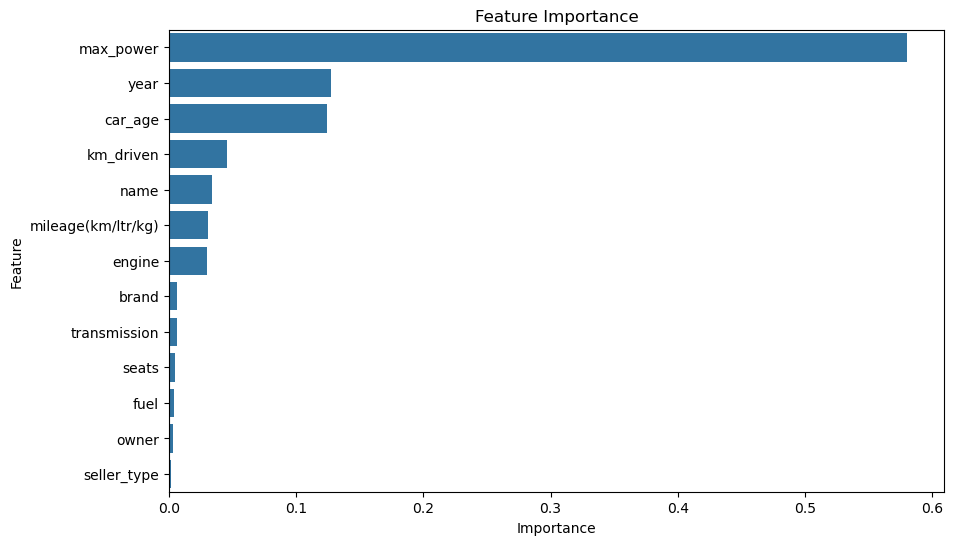

In [23]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

In [24]:
best_model = comparison.loc[comparison["R2 Score"].idxmax()]

print("\n")
print("="*70)
print("BEST MODEL")
print("="*70)

print(best_model)



BEST MODEL
Model       Random Forest
MAE          72929.835585
RMSE        129045.235797
R2 Score          0.92411
Name: 1, dtype: object


In [25]:

print("\nCONCLUSION")

print("""
1. Loaded the CarDekho dataset successfully.

2. Removed duplicate records and missing values.

3. Converted max_power into numeric values.

4. Created a new feature called Car Age.

5. Extracted Brand from the car name.

6. Performed Exploratory Data Analysis.

7. Encoded categorical variables.

8. Displayed the correlation heatmap.

9. Split the data into training and testing sets.

10. Trained two regression models:
   • Linear Regression
   • Random Forest Regressor

11. Evaluated the models using:
   • MAE
   • RMSE
   • R² Score

12. Displayed feature importance.

13. Selected the best-performing model based on the highest R² score.
""")


CONCLUSION

1. Loaded the CarDekho dataset successfully.

2. Removed duplicate records and missing values.

3. Converted max_power into numeric values.

4. Created a new feature called Car Age.

5. Extracted Brand from the car name.

6. Performed Exploratory Data Analysis.

7. Encoded categorical variables.

8. Displayed the correlation heatmap.

9. Split the data into training and testing sets.

10. Trained two regression models:
   • Linear Regression
   • Random Forest Regressor

11. Evaluated the models using:
   • MAE
   • RMSE
   • R² Score

12. Displayed feature importance.

13. Selected the best-performing model based on the highest R² score.

